# Supplementary Material 1.3 (S1.3)

This notebook reproduces the Case IIIA collocation-sample analysis for the 1D BINN study, focusing on the constant-diffusion and linear-growth setting while varying the number of collocation points ($n_c$) used in the PDE loss.

The notebook contains:

1. A collocation-sample sweep over `numPDEsamples` $n_c \in \{10, 100, 1000\}$ at fixed architecture `(W_D, W_u) = (4, 64)` across `ES` in `{1000, 3000}`.
2. Validation-loss, diffusion-MSE, growth-MSE, and runtime comparisons for  models from that sweep.
3. Loss-component diagnostics and learned diffusion/growth trajectories across the same collocation grid.

*It produces Fig. S5 in the supplementary material.*

In [2]:
import os
import sys
from pathlib import Path

import numpy as np

PROJECT_ROOT = next(
    path
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "Training").is_dir()
)
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

from Training.JN.notebook_helpers.notebook_config import (
    BCbool,
    BNdataLossFuncLabel,
    D_one_param_bool,
    binn_batch_size,
    binn_lr,
    binn_model_num,
    binn_rel_save_thresh,
    binn_rel_update_thresh,
    binnDevice,
    binnGenerateIndicesLabel,
    binnVF,
)
from Training.JN.notebook_helpers.notebook_data import (
    build_catalog,
    load_data_object,
    load_original_data,
)
from Training.JN.notebook_helpers.notebook_models import (
    active_constraint_settings,
    build_model_catalog,
    load_requested_models,
    resolve_model_path_from_catalog,
)
from Training.JN.notebook_helpers.notebook_setup import bootstrap_notebook, register_notebook_pickle_globals

paths = bootstrap_notebook(PROJECT_ROOT)
PROJECT_ROOT = paths.project_root
JN_ROOT = paths.notebook_root
DATA_ROOT = paths.data_root
BINN_ROOT = paths.binn_root

register_notebook_pickle_globals()

from paper_helpers import (
    condense_df,
    scale_function_by_percent_error,
    plot_diffusion_across_epochs,
    plot_growth_across_epochs,
    plot_running_min_MSE_diff_loss_broken_x_log_lst,
    plot_running_min_MSE_grow_loss_broken_x_log_lst,
    plot_running_min_loss_component_broken_x_log_lst,
    plot_running_min_loss_components_seed_broken_x_log_lst,
    plot_total_run_times_lst,
)

## 1. Load the Case IIIA data

We first recover the simulated constant-diffusion, linear-growth dataset used throughout the Case IIIA analysis, verifying that the data object exists on disk before any model analysis begins. The spatial and temporal grids follow [Lagergren et al. (2020)](https://doi.org/10.1371/journal.pcbi.1008462)

In [3]:
# Load the shared spatial and temporal coordinates from Lagergren et al. (2020).
original_data_obj = load_original_data(DATA_ROOT)
x = original_data_obj.x
t = original_data_obj.t
K = 1

# Shared data-object catalogue used by this notebook.
data_df = build_catalog(DATA_ROOT, target_filename="data_obj.npy")

CASE3A_DATA_CONFIG = {
    "dataX1num": 38,
    "dataX2num": 1,
    "dataTnum": 5,
    "dataK": 1,
    "dataICLabel": "cos",
    "dataDiffLabel": "const",
    "dataGrowLabel": "linear",
    "dataGamma": 0,
    "dataNoisePercent": 0,
    "dataNoiseSeed": 0,
}

data_obj, _ = load_data_object(
    CASE3A_DATA_CONFIG,
    DATA_ROOT,
    data_df=data_df,
)

## 2. Build the Case IIIA model catalogue & form helper functions for model loading and plotting

### 2.1. Catalogue trained model

Next we catalogue all saved BINN checkpoints under `Training/binn`, filter them to the fixed Case IIIA assumptions, and verify that the expected trained models exist before any figure generation begins.

The varying dimensions in this notebook are `numPDEsamples`, `binnES`, `binnDsize`, `binnUsize`, and `binnTVsplitSeed`; everything else is held fixed for Case IIIA.

In [4]:
# Catalogue of all saved BINN checkpoints across the training study.
binn_df = build_model_catalog(BINN_ROOT)

FIXED_G_WIDTH = 4
ALL_CONSTRAINTS = True
CONSTRAINT_TUPLE = (True, True, True, True)
CONSTRAINT_WEIGHTS = {
    "D_bound_weight": 0,
    "D_mono_weight": 1e1,
    "G_bound_weight": 0,
    "G_mono_weight": 1e1,
}
CONSTRAINT_BOUNDS = {
    "D_bound": (0, 0.1),
    "G_bound": (-0.02 / (1 / 24), 0.1 / (1 / 24)),
}
CONSTRAINT_SETTINGS = active_constraint_settings(
    CONSTRAINT_TUPLE,
    CONSTRAINT_WEIGHTS,
    CONSTRAINT_BOUNDS,
)

CASE3A_FIXED_FILTERS = CASE3A_DATA_CONFIG | {
    "binnVF": binnVF,
    "binnGenerateIndicesLabel": binnGenerateIndicesLabel,
    "binnGsize": FIXED_G_WIDTH,
    "DoneParamBool": D_one_param_bool,
    "binnDevice": binnDevice,
    "allConstraints": ALL_CONSTRAINTS,
    **CONSTRAINT_SETTINGS,
    "BCbool": BCbool,
    "BNdataLossFuncLabel": BNdataLossFuncLabel,
    "binnLR": binn_lr,
    "binnBatchSize": binn_batch_size,
    "binnRelUpdateThresh": binn_rel_update_thresh,
    "binnRelSaveThresh": binn_rel_save_thresh,
    "binnModelLabel": binn_model_num,
}

case3a_catalog = condense_df(binn_df, CASE3A_FIXED_FILTERS)
if case3a_catalog.empty:
    raise FileNotFoundError(
        "No BINN models found for constant diffusion + linear growth with filters:\n"
        f"{CASE3A_FIXED_FILTERS}"
    )

### 2.2. Helper functions for loading trained models

In [5]:
U_WIDTHS = [64]
D_WIDTHS = [4]
SELECTED_D_WIDTH = 4
ES_VALUES = [1000, 3000]
SELECTED_ES = ES_VALUES[0]
TV_SPLIT_SEEDS = [0, 1, 2]
NUM_PDE_SAMPLES_VALUES = [10, 100, 1000]
SELECTED_NUM_PDE_SAMPLES = NUM_PDE_SAMPLES_VALUES[0]
SELECTED_U_WIDTH = U_WIDTHS[-1]


def build_case3a_dynamic_filters(d_width, u_width, split_seed, binn_es, num_pde_samples=None):
    return {
        "binnTVsplitSeed": split_seed,
        "binnUsize": u_width,
        "binnDsize": d_width,
        "binnGsize": FIXED_G_WIDTH,
        "binnES": binn_es,
        "numPDEsamples": SELECTED_NUM_PDE_SAMPLES if num_pde_samples is None else num_pde_samples,
        "BNdataLossFuncLabel": BNdataLossFuncLabel,
        **CONSTRAINT_SETTINGS,
    }


def load_case3a_models(es_values, d_sizes, u_sizes, split_seeds, num_pde_samples=None):
    requested_models = [
        {
            "binnES": binn_es,
            "binnDsize": d_width,
            "binnUsize": u_width,
            "binnTVsplitSeed": split_seed,
            "path": resolve_model_path_from_catalog(
                case3a_catalog,
                CASE3A_FIXED_FILTERS,
                build_case3a_dynamic_filters(
                    d_width,
                    u_width,
                    split_seed,
                    binn_es,
                    num_pde_samples=num_pde_samples,
                ),
                model_label=binn_model_num,
            ),
        }
        for binn_es in es_values
        for d_width in d_sizes
        for u_width in u_sizes
        for split_seed in split_seeds
    ]
    return load_requested_models(
        requested_models,
        device=binnDevice,
        group_keys=("binnES", "binnDsize", "binnUsize", "binnTVsplitSeed"),
        missing="ignore",
    )

### 2.3 Shared plotting style

These settings define the common colour palettes, plotting helpers, and reference MSE guide-lines used across the Case IIIA figures.

In [6]:
BLUE_COLORS = [
    "#0033A0",
    "#1E90FF",
    "#6699CC",
    "#A4C8E1",
    "#D6EAF8",
]

D_COLORS = [
    "#8B2500",
    "#FF7F0E",
    "#FDB863",
    "#FDD9B5",
    "#FFF1E0",
]

G_COLORS = [
    "#00441B",
    "#1A9850",
    "#66C2A4",
    "#B2E2E2",
    "#E5F5F9",
]

PURPLE_COLORS = [
    '#f2f0f7',
    '#c7c8e1',
    '#999fcb',
    '#7b80bc',
    '#4a3298'
][::-1]

PINK_COLORS = [
    '#feebe2',
    '#fbafba',
    '#f57094',
    '#e73c7e',
    '#9b0079'
][::-1]

linestyles = ["-"] * 5
MARKER_STYLES = ["o"] * 5
hatch_patterns = ("////", "....", "ooo", "***")
figsize = (7, 5)
rawMSEs = [0.25, 0.5, 1]
AXIS_FONTSIZES = {
    "xaxis": 18,
    "xtick_labels": 18,
    "yaxis": 18,
    "ytick_labels": 18,
}


def plot_params_from_models(models_dics, colors):
    model_keys = list(models_dics.keys())
    return {
        key: [colors[i], linestyles[i], MARKER_STYLES[i], str(key)]
        for i, key in enumerate(model_keys)
    }


def ground_truth_diffusion(u):
    return data_obj.theta_D * np.ones_like(u)


def ground_truth_growth(u):
    return data_obj.theta_G[0] + data_obj.theta_G[1] * u


diff_mses = [
    scale_function_by_percent_error(ground_truth_diffusion, beta=mse)[1]
    for mse in rawMSEs
]

# Output directory for the Case IIIA figures.
name_intro = JN_ROOT / "pngs" / "1D" / "case3" / "figS5"
os.makedirs(name_intro, exist_ok=True)

## 3. Collocation-sample sweep: vary `numPDEsamples` at fixed `(W_D, W_u) = (4, 64)`

The figures below compare validation loss, diffusion MSE, growth MSE, runtime, optimizer diagnostics, and learned trajectories as `numPDEsamples` varies at fixed architecture.

SORTED ['10', '100', '1000']


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_running_min.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_a


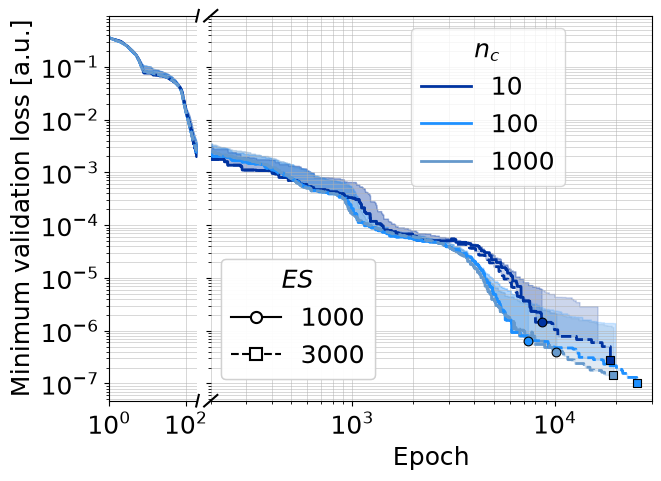

/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_mse_running_min.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_d


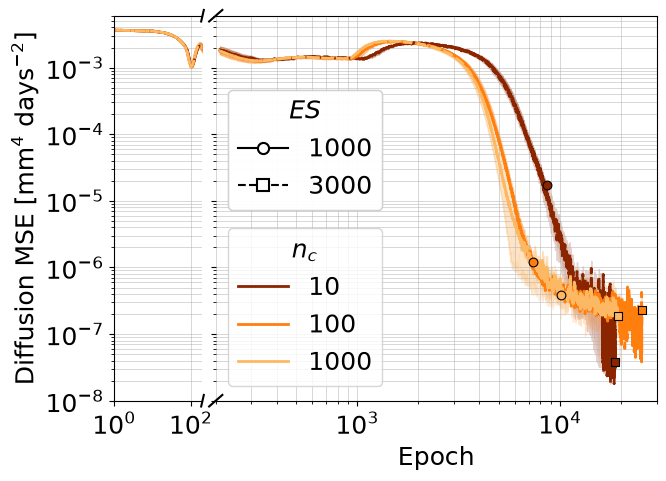

/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_mse_running_min_growth.py:437: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_e


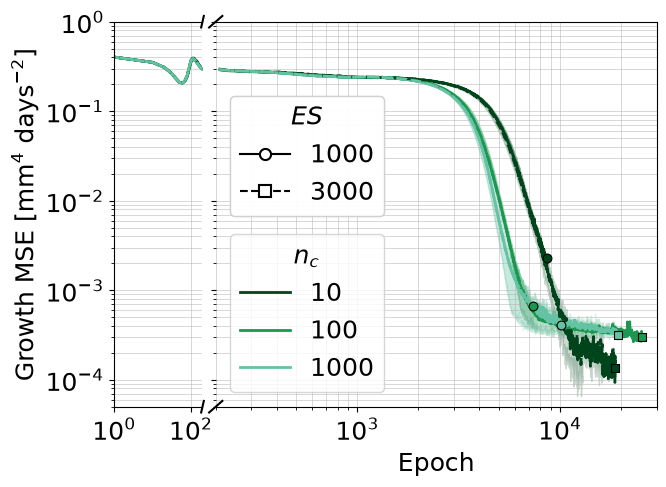

All x-axis labels found (ordered): ['10', '100', '1000']
Mean runtime increases between corresponding models across groups:
  1000 -> 3000
    10: 126.773s -> 267.683s (delta +140.909s)
    100: 173.124s -> 352.883s (delta +179.759s)
    1000: 571.453s -> 1399.246s (delta +827.793s)
    mean delta: +382.821s
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_b


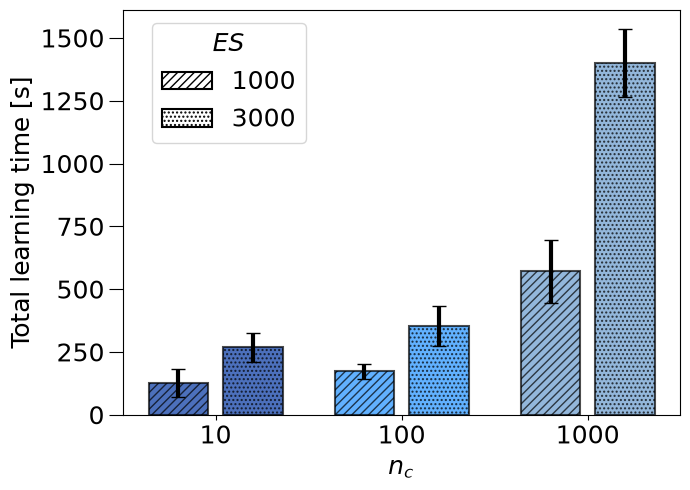

/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_components.py:673: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(left=xaxis["min"], right=xaxis["break"])
/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_components.py:1236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_c


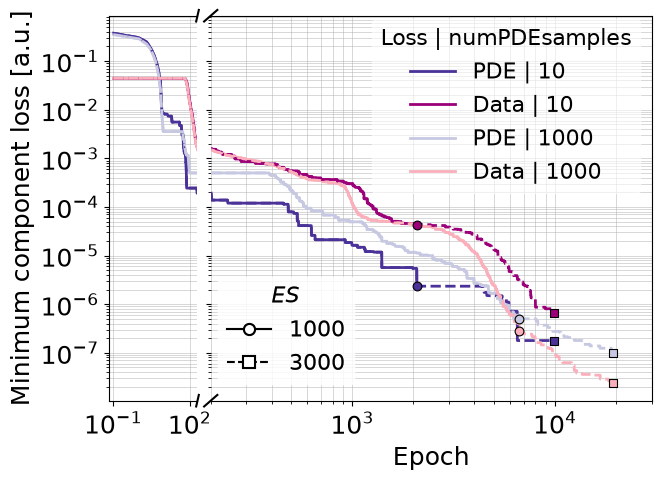

Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_LHS_f_diffusion_group_1_model0_ylim_0p015_0p11.png


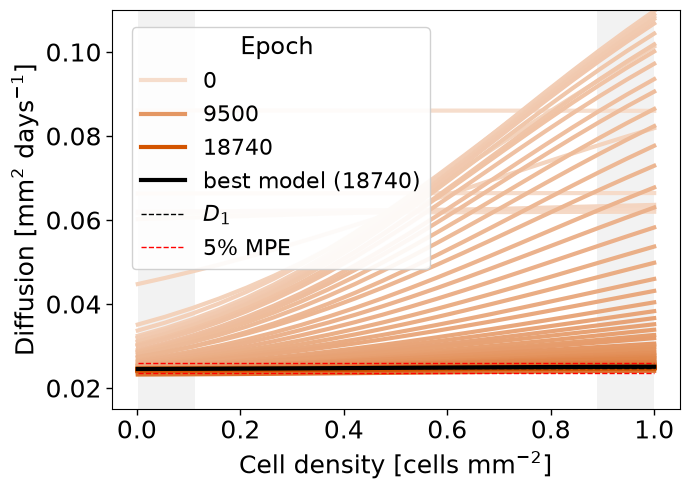

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_LHS_f_diffusion_group_1_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_LHS_f_diffusion_group_1_model0_ylim_0p0234_0p026.png


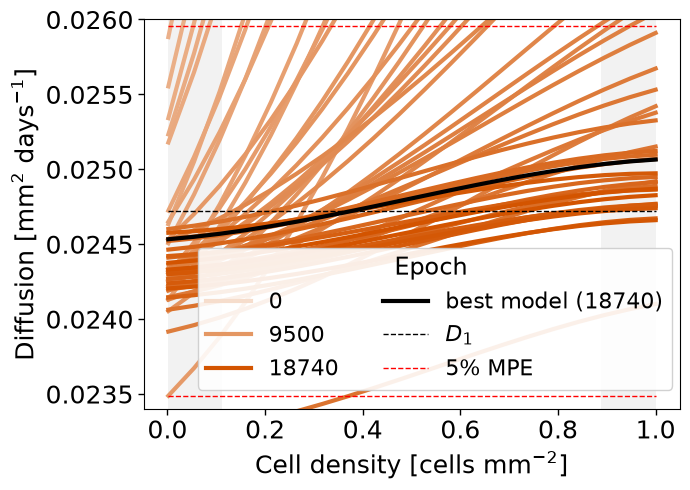

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_LHS_f_diffusion_group_1_model0_ylim_0p0234_0p026.png
Overwriting existing growth plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_RHS_f_growth_group_1_model0.png


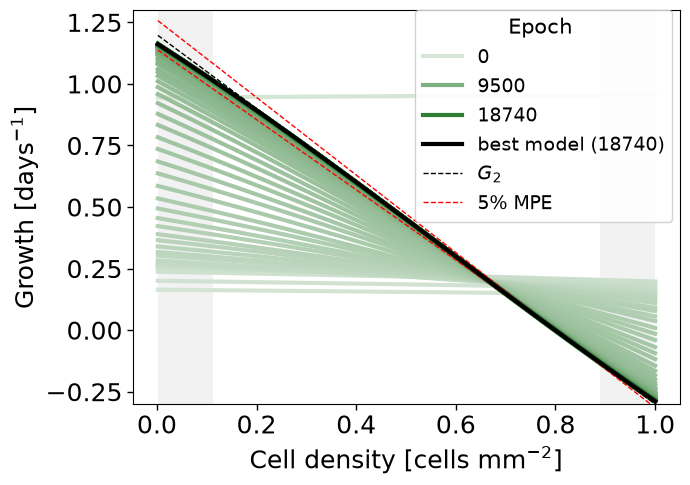

Saved growth plot for group_1, model_index=0, y_lim=(-0.3, 1.3): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_RHS_f_growth_group_1_model0.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_LHS_g_diffusion_group_1_model0_ylim_0p015_0p11.png


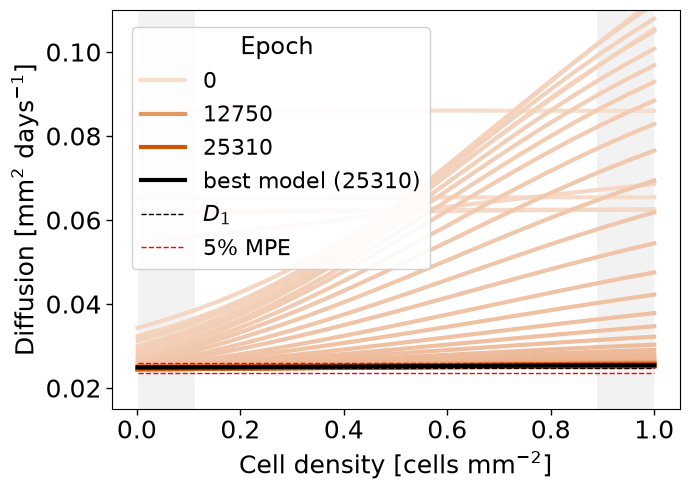

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_LHS_g_diffusion_group_1_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_LHS_g_diffusion_group_1_model0_ylim_0p0234_0p026.png


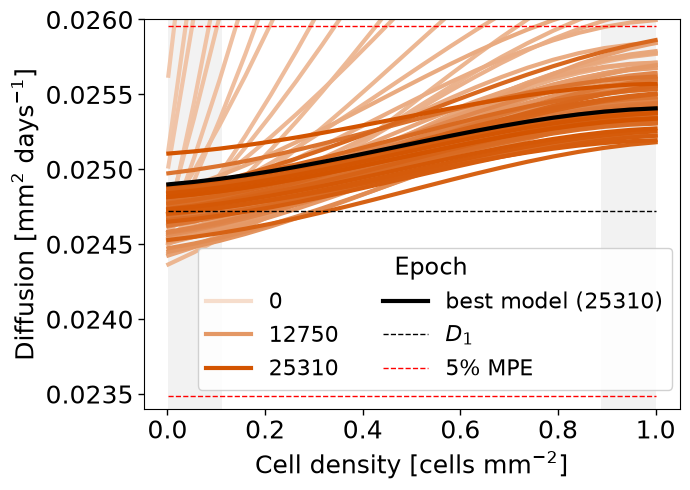

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_LHS_g_diffusion_group_1_model0_ylim_0p0234_0p026.png
Overwriting existing growth plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_RHS_g_growth_group_1_model0.png


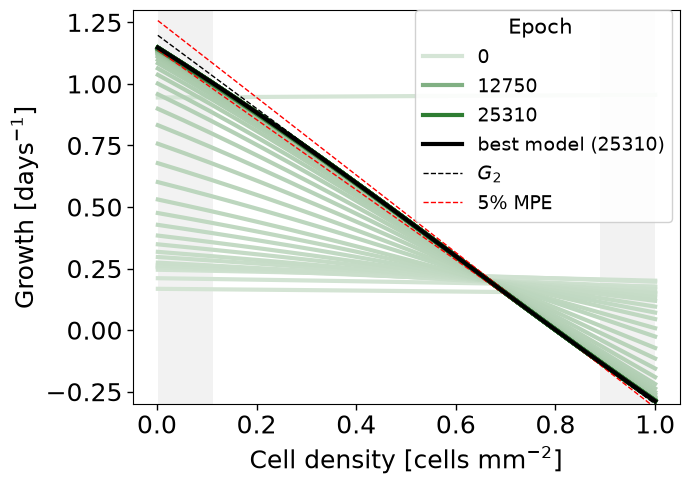

Saved growth plot for group_1, model_index=0, y_lim=(-0.3, 1.3): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_RHS_g_growth_group_1_model0.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_LHS_h_diffusion_group_1_model0_ylim_0p015_0p11.png


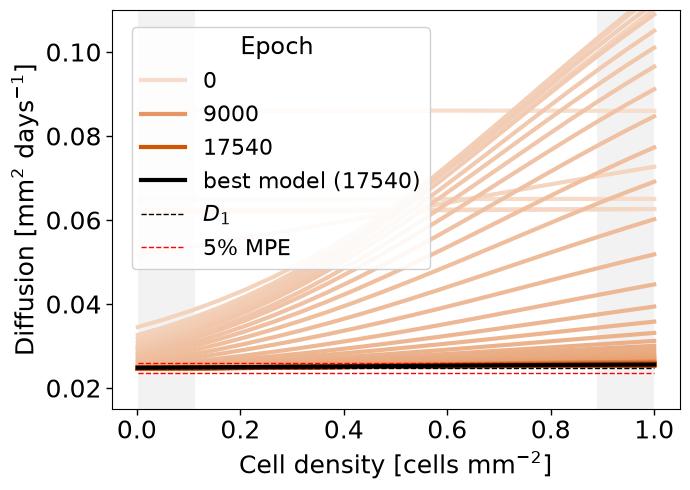

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_LHS_h_diffusion_group_1_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_LHS_h_diffusion_group_1_model0_ylim_0p0234_0p026.png


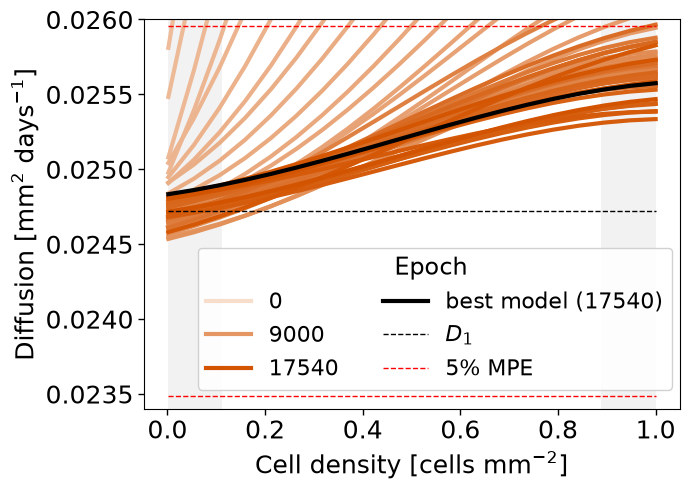

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_LHS_h_diffusion_group_1_model0_ylim_0p0234_0p026.png
Overwriting existing growth plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_RHS_h_growth_group_1_model0.png


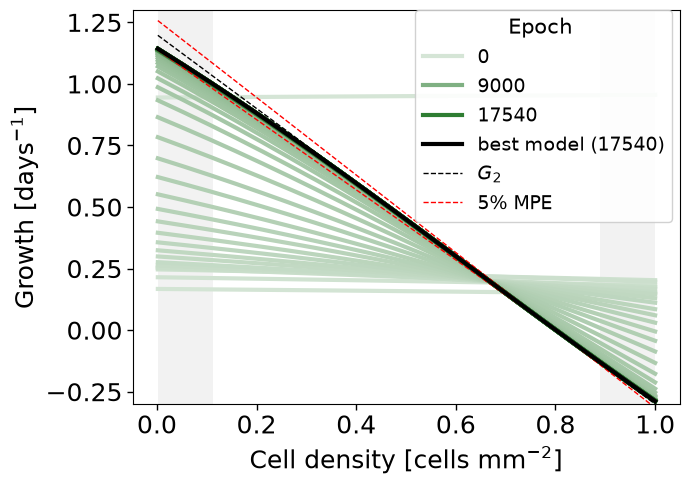

Saved growth plot for group_1, model_index=0, y_lim=(-0.3, 1.3): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figS5/plot_RHS_h_growth_group_1_model0.png


In [7]:
binn_models_by_num_pde_samples = {
    n: load_case3a_models(
        es_values=ES_VALUES,
        d_sizes=D_WIDTHS,
        u_sizes=U_WIDTHS,
        split_seeds=TV_SPLIT_SEEDS,
        num_pde_samples=n,
    )
    for n in NUM_PDE_SAMPLES_VALUES
}
binn_models_by_es = binn_models_by_num_pde_samples[SELECTED_NUM_PDE_SAMPLES]

if not binn_models_by_es:
    raise FileNotFoundError("No loadable constant-D / linear-growth BINN checkpoints were found.")

vary_num_pde_models_selected_arch = {
    n: binn_models_by_num_pde_samples[n][SELECTED_ES][SELECTED_D_WIDTH][SELECTED_U_WIDTH]
    for n in NUM_PDE_SAMPLES_VALUES
}

vary_es_models_selected_es = binn_models_by_es[ES_VALUES[0]]
vary_es_models_selected_d = vary_es_models_selected_es[SELECTED_D_WIDTH]

plot_params = plot_params_from_models(vary_es_models_selected_d, BLUE_COLORS)
plot_params_growth = plot_params_from_models(vary_es_models_selected_d, G_COLORS)
plot_params_num_pde_diff = plot_params_from_models(vary_num_pde_models_selected_arch, D_COLORS)
plot_params_num_pde_growth = plot_params_from_models(vary_num_pde_models_selected_arch, G_COLORS)
plot_params_num_pde_u = plot_params_from_models(vary_num_pde_models_selected_arch, BLUE_COLORS)


maxEpochs = 3e4
breakEpoch = 2e2
diffMin = 1e-8
growMin = 5e-5

num_pde_palette_idx = np.linspace(
    0,
    len(PURPLE_COLORS) - 2,
    len(NUM_PDE_SAMPLES_VALUES),
    dtype=int,
).tolist()

num_pde_purple_colors = [PURPLE_COLORS[i] for i in num_pde_palette_idx]
num_pde_pink_colors = [PINK_COLORS[i] for i in num_pde_palette_idx]
num_pde_g_colors = [G_COLORS[i] for i in num_pde_palette_idx]

num_pde_color_indices = [
    num_idx
    for _ in ES_VALUES
    for num_idx, _ in enumerate(NUM_PDE_SAMPLES_VALUES)
]

num_pde_marker_indices = [
    es_idx
    for es_idx, _ in enumerate(ES_VALUES)
    for _ in NUM_PDE_SAMPLES_VALUES
]

num_pde_d_colour_by_value = {
    n: num_pde_pink_colors[i]
    for i, n in enumerate(NUM_PDE_SAMPLES_VALUES)
}

num_pde_g_colour_by_value = {
    n: num_pde_g_colors[i]
    for i, n in enumerate(NUM_PDE_SAMPLES_VALUES)
}

vary_num_pde_models_by_es_selected_arch = [
    {
        n: binn_models_by_num_pde_samples[n][ES][SELECTED_D_WIDTH][SELECTED_U_WIDTH]
        for n in NUM_PDE_SAMPLES_VALUES
    }
    for ES in ES_VALUES
]

num_pde_es_entries = [
    (str(ES), marker)
    for ES, marker in zip(ES_VALUES, ["o", "s", "D", "^", "v", "P"])
]

num_pde_group_labels = [f"ES {ES}" for ES in ES_VALUES]

vary_num_pde_models_flat = [
    binn_models_by_num_pde_samples[n][ES][SELECTED_D_WIDTH][SELECTED_U_WIDTH]
    for ES in ES_VALUES
    for n in NUM_PDE_SAMPLES_VALUES
]

num_pde_es_group_labels = [
    str(n)
    for _ in ES_VALUES
    for n in NUM_PDE_SAMPLES_VALUES
]

figsize = (7, 5)
minEpoch = 0

maxEpoch = 3e4
breakEpoch = 2e2
epochAxis = {"min": minEpoch, "max": maxEpoch, "break": breakEpoch}
LEGEND_SIZE = 18


num_pde_plot_settings = {
    "name": str(name_intro /"plot_a"),
    "fill": True,
    "line_width": 2,
    "colors": num_pde_purple_colors,
    "legend": {
        "panel": 2,
        "loc": (0.425, 1),
        "loc_upd": (0.4, 0.4),
        "fontsize": LEGEND_SIZE,
        "ncols": 1,
        "title": "$n_c$",
        "marker_title": "$ES$",
    },
    "xaxis": epochAxis,
    "fontsizes": AXIS_FONTSIZES,
    "figsize": figsize,
    "es_entries": num_pde_es_entries,
    "ylabel": "Minimum validation loss [a.u.]",
}

plot_running_min_loss_component_broken_x_log_lst(
    models_dics_list=vary_num_pde_models_by_es_selected_arch,
    plot_params=plot_params_num_pde_u,
    plot_settings=num_pde_plot_settings,
    loss_attr="val_loss_list",
)

num_pde_plot_settings = {
    "name": str(name_intro /"plot_d"),
    "fill": True,
    "line_width": 2,
    "colors": num_pde_pink_colors,
    "legend": {
        "panel": 2,
        "loc": (0, 0.48),
        "loc_upd": (0, 0.84),
        "fontsize": LEGEND_SIZE,
        "ncols": 1,
        "title": "$n_c$",
        "marker_title": "$ES$",
    },
    "xaxis": epochAxis,
    "fontsizes": AXIS_FONTSIZES,
    "figsize": figsize,
    "ylim": (diffMin, 0.6e-2),
    "es_entries": num_pde_es_entries,
    
}

plot_running_min_MSE_diff_loss_broken_x_log_lst(
    models_dics_list=vary_num_pde_models_by_es_selected_arch,
    plot_params=plot_params_num_pde_diff,
    plot_settings=num_pde_plot_settings,
)

num_pde_plot_settings = {
    "name": str(name_intro /"plot_e"),
    "fill": True,
    "line_width": 2,
    "colors": num_pde_g_colors,
    "legend": {
        "panel": 2,
        "loc": (0.41, 0.48),
        "loc_upd": (0.41, 0.84),
        "fontsize": LEGEND_SIZE,
        "ncols": 1,
        "title": "$n_c$",
        "marker_title": "$ES$",
    },
    "xaxis": {"min": 0, "max": maxEpochs, "break": breakEpoch},
    "fontsizes": AXIS_FONTSIZES,
    "figsize": figsize,
    "ylim": (growMin, 1e0),
    "es_entries": num_pde_es_entries,
}

plot_running_min_MSE_grow_loss_broken_x_log_lst(
    models_dics_list=vary_num_pde_models_by_es_selected_arch,
    plot_params=plot_params_num_pde_growth,
    plot_settings=num_pde_plot_settings,
)

plot_total_run_times_lst(
    models_dics_list=vary_num_pde_models_by_es_selected_arch,
    plot_params=plot_params_num_pde_u,
    label_list=[f"{ES}" for ES in ES_VALUES],
    name=str(name_intro /"plot_b"),
    legend_pos=(0.35, 1),
    legend_fontsize=LEGEND_SIZE,
    legend_title="$ES$",
    y_label="Total learning time [s]",
    x_label=r"$n_c$",
    figsize=figsize,
    axis_fontsizes=AXIS_FONTSIZES,
    hatch_patterns=("////", "....", "ooo", "***"),
    y_scale= 'linear'
)

num_pde_samples_components = [10, 1000]
num_pde_component_palette_idx = [
    NUM_PDE_SAMPLES_VALUES.index(n)
    for n in num_pde_samples_components
]
num_pde_component_purple_colors = [
    num_pde_purple_colors[i] for i in num_pde_component_palette_idx
]
num_pde_component_pink_colors = [
    num_pde_pink_colors[i] for i in num_pde_component_palette_idx
]

vary_num_pde_component_models_flat = [
    binn_models_by_num_pde_samples[n][ES][SELECTED_D_WIDTH][SELECTED_U_WIDTH]
    for ES in ES_VALUES
    for n in num_pde_samples_components
]
num_pde_component_color_indices = [
    num_idx
    for _ in ES_VALUES
    for num_idx, _ in enumerate(num_pde_samples_components)
]
num_pde_component_marker_indices = [
    es_idx
    for es_idx, _ in enumerate(ES_VALUES)
    for _ in num_pde_samples_components
]
num_pde_component_group_labels = [
    str(n)
    for _ in ES_VALUES
    for n in num_pde_samples_components
]

num_pde_plot_settings = {
    "fill": True,
    "line_width": 2,
    "colors": num_pde_g_colors,
    "legend": {
        "panel": 2,
        "loc": (0.34, 1.02),
        "loc_upd": (0.35, 0.35),
        "fontsize": 16,#LEGEND_SIZE,
        "ncols": 1,
        "title": "$n_c$",
        "marker_title": "$ES$",
    },
    "xaxis": {"min": 0, "max": maxEpochs, "break": breakEpoch},
    "fontsizes": AXIS_FONTSIZES,
    "figsize": figsize,
    "ylim": (growMin, 1e0),
    "es_entries": num_pde_es_entries,
    "ylabel": "Minimum component loss [a.u.]",
}

num_pde_component_seed = 0
num_pde_component_smoothing_window = 100

num_pde_component_plot_settings = {
    **num_pde_plot_settings,
    "name": str(
        name_intro / "plot_c"
    ),
    "colors": num_pde_component_purple_colors,
    "color_indices": num_pde_component_color_indices,
    "marker_indices": num_pde_component_marker_indices,
    "es_entries": num_pde_es_entries,
    "legend": {
        **num_pde_plot_settings["legend"],
        "title": "Loss | numPDEsamples",
    },
}

plot_running_min_loss_components_seed_broken_x_log_lst(
    models_dics_list=vary_num_pde_component_models_flat,
    plot_settings=num_pde_component_plot_settings,
    legend_labels=num_pde_component_group_labels,
    legend_label_title="Loss | numPDEsamples",
    seed=num_pde_component_seed,
    components={
        "pde": {
            "colors": num_pde_component_purple_colors,
            "palette": (
                num_pde_component_purple_colors[0],
                num_pde_component_purple_colors[-1],
            ),
        },
        "data": {
            "colors": num_pde_component_pink_colors,
            "palette": (
                num_pde_component_pink_colors[0],
                num_pde_component_pink_colors[-1],
            ),
        },
    },
)




for label, num_pde_samples in zip(["f", "g", "h"], NUM_PDE_SAMPLES_VALUES):
    models_by_es_for_num_pde = binn_models_by_num_pde_samples[num_pde_samples]
    models_for_num_pde = models_by_es_for_num_pde[ES_VALUES[1]][SELECTED_D_WIDTH]

    for Wu in U_WIDTHS:
        plot_settings = {
            "name": str(
                name_intro
                / f"plot_LHS_{label}.png"
            ),
            "fill": True,
            "line_width": 2,
            "colors": [num_pde_d_colour_by_value[num_pde_samples]],
            "legends": [
                {
                    "loc": (0.035, 0.35),   # for y_lims[0] = (0.015, 0.11)
                    "fontsize": 16,
                    "ncols": 1,
                    "framealpha": 0.9,
                },
                {
                    "loc": (0.1, 0.05),  # for y_lims[1] = (0.0234, 0.026)
                    "fontsize": 16,
                    "ncols": 2,
                    "framealpha": 0.9,
                },
            ],
            "xaxis": epochAxis,
            "fontsizes": AXIS_FONTSIZES,
            "figsize": figsize,
            "y_lims": [(0.015, 0.11), (0.0234, 0.026)],
            "mpe": 5,
            "epoch_step": 25,
            "epoch_sf": 10,
            "D_true_label": r"$D_1$",
        }


        plot_diffusion_across_epochs(
            overwrite=True,
            models_dics_list=[models_for_num_pde[Wu]],
            plot_params=plot_params,
            plot_settings=plot_settings,
            seed_index=1,
            shade_outside_central_90=True,
        )

        plot_settings = {
            "name": str(name_intro / f"plot_RHS_{label}.png"),
            "fill": True,
            "line_width": 2,
            "colors": [num_pde_g_colour_by_value[num_pde_samples]],
            "legend": {
                "panel": 2,
            "loc": (0.516, 0.463),   # fallback for any plot without an override
                "fontsize": 14,
                "ncols": 1,
                "framealpha": 0.9,
            },
            "xaxis": epochAxis,
            "fontsizes": AXIS_FONTSIZES,
            "figsize": figsize,
            "y_lims": [(-0.3, 1.3)],
            "mpe": 5,
            "epoch_step": 25,
            "epoch_sf": 10,
            "G_true_label": r"$G_2$",
        }

        plot_growth_across_epochs(
            overwrite=True,
            models_dics_list=[models_for_num_pde[Wu]],
            plot_params=plot_params_growth,
            plot_settings=plot_settings,
            seed_index=1,
            shade_outside_central_90=True,
        )


## References

J. H. Lagergren et al. "Biologically-informed neural networks guide mechanistic modeling from sparse experimental data". In: *PLoS Comput Biol* 16.12 (2020), e1008462. DOI: [10.1371/journal.pcbi.1008462](https://doi.org/10.1371/journal.pcbi.1008462).
